# 01 Comprension Calidad Target

Comprensión, target, calidad, hipótesis.



> Ejecutar la celda **init** (`%run init_notebook.py`) y luego **carga** según el notebook.


In [1]:
%run init_notebook.py


Project root: C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica
Train data:   C:\Users\Usuario\code\miia\proyecto_1_innovacion_tecnologica\data\raw\train.csv


In [2]:
df = load_raw_train()


Dimensiones del dataset: (3960, 82)
         id Basic_Demos-Enroll_Season  Basic_Demos-Age  Basic_Demos-Sex  \
0  00008ff9                      Fall                5                0   
1  000fd460                    Summer                9                0   
2  00105258                    Summer               10                1   
3  00115b9f                    Winter                9                0   
4  0016bb22                    Spring               18                1   

  CGAS-Season  CGAS-CGAS_Score Physical-Season  Physical-BMI  Physical-Height  \
0      Winter             51.0            Fall     16.877316             46.0   
1         NaN              NaN            Fall     14.035590             48.0   
2        Fall             71.0            Fall     16.648696             56.5   
3        Fall             71.0          Summer     18.292347             56.0   
4      Summer              NaN             NaN           NaN              NaN   

   Physical-Weight  ...  P

## 3. Comprensión Inicial del Dataset

### 3.1 Información general

In [3]:
# ==============================
# INFORMACIÓN GENERAL
# ==============================

print("\nTIPOS DE DATOS")
print(df.dtypes.value_counts())

print("\nINFORMACIÓN GENERAL")
df.info()



TIPOS DE DATOS
float64    68
object     12
int64       2
Name: count, dtype: int64

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   object 
 1   Basic_Demos-Enroll_Season               3960 non-null   object 
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   object 
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   object 
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight         

El dataset contiene variables numéricas y categóricas relacionadas con condición física, biometría, sueño, hábitos digitales y desempeño físico de niños y adolescentes. Estas variables serán utilizadas para predecir el nivel de uso problemático de internet (sii).

### 3.2 Familias de variables

La consigna del proyecto pide predecir el nivel de uso problemático de internet en función de la **actividad física y la condición física** de los participantes. Para que el EDA y la justificación de cada decisión queden claras, agrupamos las 82 columnas originales por familia conceptual.

| Familia | Relación con la consigna | Ejemplos |
|---|---|---|
| Identificador (`id`) | Sin uso predictivo | `id` |
| **Target** (`sii`) | Severity Impairment Index del PCIAT (0/1/2/3) | `sii` |
| Demográficas | Contexto del individuo | `Basic_Demos-Age`, `Basic_Demos-Sex` |
| Clínicas | Estado clínico general | `CGAS-CGAS_Score` |
| **Físicas / antropométricas** | Condición física | `Physical-BMI`, `Physical-Height`, `Physical-Weight`, `Physical-HeartRate` |
| **Fitness / resistencia** | Actividad física | `Fitness_Endurance-Max_Stage`, `Fitness_Endurance-Time_Mins` |
| **FitnessGram** (fuerza/flexibilidad) | Condición física | `FGC-FGC_CU`, `FGC-FGC_PU`, `FGC-FGC_TL` |
| **Biométricas (BIA)** | Composición corporal | `BIA-BIA_BMI`, `BIA-BIA_Fat`, `BIA-BIA_SMM` |
| **Actividad física (PAQ)** | Núcleo de la consigna | `PAQ_C-PAQ_C_Total`, `PAQ_A-PAQ_A_Total` |
| Internet / hábitos | Variable más cercana al target | `PreInt_EduHx-computerinternet_hoursday` |
| Sueño (SDS) | Hábitos de salud asociados | `SDS-SDS_Total_Raw`, `SDS-SDS_Total_T` |
| **PCIAT** (NO usar) | Construyen el target → leakage | `PCIAT-PCIAT_01..20`, `PCIAT-PCIAT_Total` |

Las familias en negrita son las más alineadas con la consigna y serán el foco principal del EDA en las secciones 11 y 12. Las variables `PCIAT-*` se excluirán del modelado por leakage (sección 10.2).

#### Codificaciones relevantes

Algunas variables clave del dataset usan codificaciones específicas que conviene tener presentes al interpretar gráficos y tablas:

| Variable | Codificación |
|---|---|
| `sii` (target) | `0` = None, `1` = Mild, `2` = Moderate, `3` = Severe |
| `Basic_Demos-Sex` | `0` = varón, `1` = mujer |
| `PreInt_EduHx-computerinternet_hoursday` | `0` = < 1 h/día, `1` ≈ 1 h/día, `2` ≈ 2 h/día, `3` = > 3 h/día |
| `FGC-*_Zone` (FitnessGram) | Zona de condición física (p. ej. *Need Improvement* / *Healthy Fitness Zone*) |
| `*-Season` | Estación del año en la que se hizo la medición (`Spring`, `Summer`, `Fall`, `Winter`) |
| `BIA-BIA_Activity_Level_num` | Nivel de actividad declarado (escala numérica) |
| `BIA-BIA_Frame_num` | Tipo de complexión corporal (`Small`, `Medium`, `Large`) en codificación numérica |

`PreInt_EduHx-computerinternet_hoursday` está codificada como **categoría ordinal**, no como horas continuas: el valor `3` representa "más de 3 horas", no exactamente 3.

In [4]:
id_col = ID_COLUMNS
pciat = pciat_columns()
target = TARGET_COLUMN

print("=" * 55)
print("CONTEO DE COLUMNAS POR FAMILIA")
print("=" * 55)
total = 0
for nombre, lista in VARIABLE_CATEGORIES.items():
    cantidad = len(lista)
    total += cantidad
    print(f"{nombre:32s} -> {cantidad:3d} columnas")
print("=" * 55)
print(f"{'TOTAL':32s} -> {total:3d}")


CONTEO DE COLUMNAS POR FAMILIA
Identificador (id)               ->   1 columnas
Target (sii)                     ->   1 columnas
Demograficas                     ->   3 columnas
Clinicas                         ->   2 columnas
Fisicas                          ->   8 columnas
Fitness / Resistencia            ->   4 columnas
FitnessGram                      ->  15 columnas
Biometricas (BIA)                ->  17 columnas
Actividad fisica (PAQ)           ->   4 columnas
Internet / Habitos               ->   2 columnas
Sueno (SDS)                      ->   3 columnas
PCIAT (NO usar - leakage)        ->  22 columnas
TOTAL                            ->  82


## 4. Análisis del Target

### 4.1 Distribución de clases

In [5]:
# ==============================
# DISTRIBUCIÓN DEL TARGET
# ==============================

target = TARGET_COLUMN

print(df[target].value_counts())
print("\nPorcentajes:")
print(df[target].value_counts(normalize=True) * 100)


sii
0.0    1594
1.0     730
2.0     378
3.0      34
Name: count, dtype: int64

Porcentajes:
sii
0.0    58.260234
1.0    26.681287
2.0    13.815789
3.0     1.242690
Name: proportion, dtype: float64


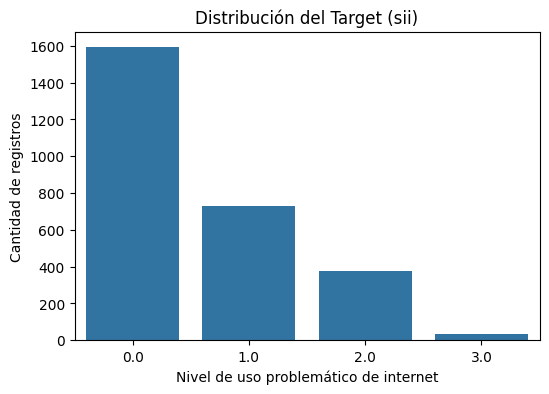

In [6]:
# Visualización de clases
plt.figure(figsize=(6,4))
sns.countplot(x=df[target])
plt.title('Distribución del Target (sii)')
plt.xlabel('Nivel de uso problemático de internet')
plt.ylabel('Cantidad de registros')
plt.show()


El dataset presenta un desbalance importante entre clases:

- Clase 0 (sin uso problemático): ~58%
- Clase 1 (leve):                  ~27%
- Clase 2 (moderado):              ~14%
- Clase 3 (severo):                ~1% (≈34 registros)

La clase 3 está tan poco representada que cualquier métrica calculada solo sobre ella tendrá altísima varianza: en una partición 80/20 el conjunto de prueba contendrá apenas 6–8 registros de esa clase. Esto debe tenerse muy presente al interpretar los resultados por clase y al diseñar la validación.

Por este desbalance, en lugar de `accuracy` reportaremos `F1 Macro` y `balanced_accuracy` (que pondera por igual cada clase), aplicaremos `class_weight='balanced'` en los modelos y compararemos con un `DummyClassifier`. En el modelado se evalúa fusionar las clases 2 y 3 (experimento de diseño); como alternativas adicionales se pueden considerar `SMOTE` o reformular como regresión ordinal.

**El target es ordinal, no nominal.** `sii` representa una severidad creciente: `0 < 1 < 2 < 3`. Esto implica que **no todos los errores son equivalentes**: predecir clase `3` cuando el real es `0` es un error mucho más grave que predecir `1` cuando el real es `0`. Las métricas nominales (`F1 Macro`, `Balanced Accuracy`) tratan a las clases como independientes y no penalizan esa distancia. Por eso, además de esas métricas, reportaremos **Cohen's Quadratic Weighted Kappa (QWK)** — la métrica oficial de la competición Kaggle — que sí incorpora la distancia ordinal entre clases. Este encuadre habilita modelos ordinales (p. ej. ridge ordinal en el pipeline de `src/`).

### 5. Calidad de Datos

### 5.1 Valores nulos

In [7]:
# ==============================
# ANÁLISIS DE NULOS
# ==============================

null_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

# Mostrar top columnas con más nulos
null_df = pd.DataFrame({
    'Variable': null_percent.index,
    'Porcentaje_Nulos': null_percent.values
})

print(null_df.head(20))


                        Variable  Porcentaje_Nulos
0                   PAQ_A-Season         88.005051
1              PAQ_A-PAQ_A_Total         88.005051
2    Fitness_Endurance-Time_Mins         81.313131
3     Fitness_Endurance-Time_Sec         81.313131
4    Fitness_Endurance-Max_Stage         81.237374
5   Physical-Waist_Circumference         77.323232
6              FGC-FGC_GSND_Zone         73.181818
7               FGC-FGC_GSD_Zone         73.156566
8                    FGC-FGC_GSD         72.878788
9                   FGC-FGC_GSND         72.878788
10      Fitness_Endurance-Season         66.969697
11             PAQ_C-PAQ_C_Total         56.540404
12                  PAQ_C-Season         56.540404
13                   BIA-BIA_ICW         49.722222
14                   BIA-BIA_DEE         49.722222
15                   BIA-BIA_ECW         49.722222
16                   BIA-BIA_FFM         49.722222
17                  BIA-BIA_FFMI         49.722222
18                   BIA-BIA_LD

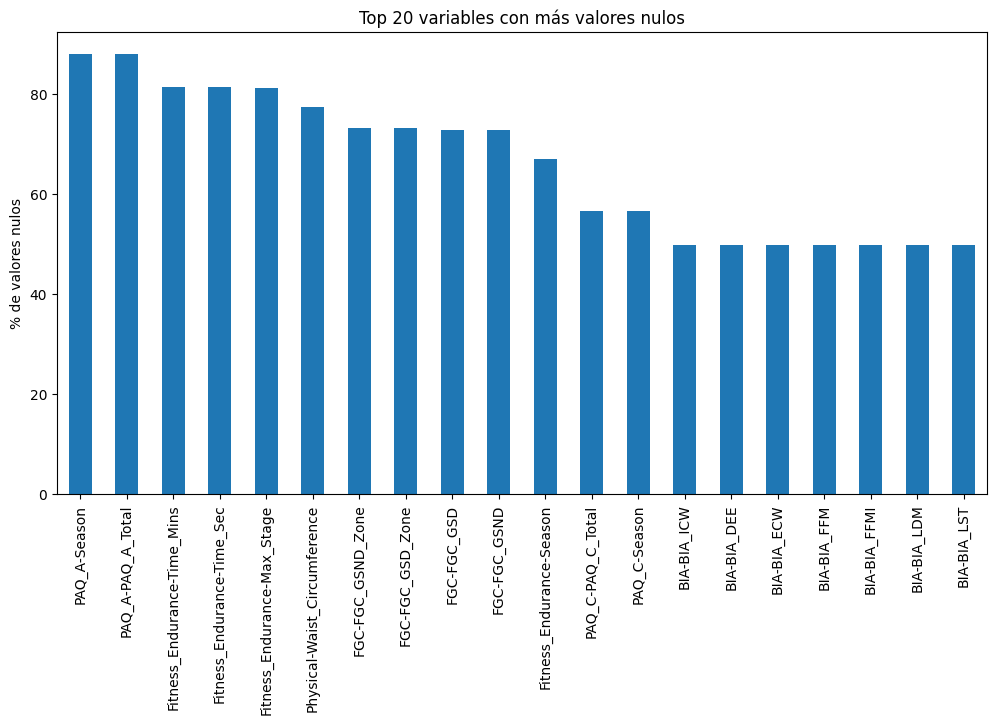

In [8]:
# Visualización de nulos
plt.figure(figsize=(12,6))

null_percent.head(20).plot(kind='bar')
plt.title('Top 20 variables con más valores nulos')
plt.ylabel('% de valores nulos')
plt.xticks(rotation=90)
plt.show()


Se identificó que varias variables presentan altos porcentajes de valores faltantes, especialmente aquellas relacionadas con actividad física y pruebas de resistencia.

Debido al nivel de ausencia de información en algunas columnas (superior al 70%), será necesario evaluar su eliminación para evitar imputaciones poco confiables.

### 5.2 Duplicados

In [9]:
# ==============================
# REGISTROS DUPLICADOS
# ==============================

duplicados = df.duplicated().sum()

print(f'Registros duplicados encontrados: {duplicados}')


Registros duplicados encontrados: 0


No se identificaron registros duplicados relevantes dentro del dataset.

### 5.3 Valores inconsistentes o imposibles

In [10]:
# ==============================
# VALORES INCONSISTENTES
# ==============================

# Variables con posibles errores fisiológicos
print('BMI iguales a 0:', (df['Physical-BMI'] == 0).sum())
print('Peso iguales a 0:', (df['Physical-Weight'] == 0).sum())
print('Altura iguales a 0:', (df['Physical-Height'] == 0).sum())
print('CGAS mayores a 100:', (df['CGAS-CGAS_Score'] > 100).sum())


BMI iguales a 0: 7
Peso iguales a 0: 61
Altura iguales a 0: 0
CGAS mayores a 100: 1


In [11]:
# Reemplazar valores inconsistentes por NaN

# BMI = 0
df.loc[df['Physical-BMI'] == 0, 'Physical-BMI'] = np.nan

# Peso = 0
df.loc[df['Physical-Weight'] == 0, 'Physical-Weight'] = np.nan

# Altura = 0
df.loc[df['Physical-Height'] == 0, 'Physical-Height'] = np.nan

# Valores imposibles en CGAS
# 999 probablemente representa dato faltante

df.loc[df['CGAS-CGAS_Score'] > 100, 'CGAS-CGAS_Score'] = np.nan


Se identificaron valores inconsistentes o fisiológicamente imposibles en algunas variables, como índices de masa corporal iguales a cero y valores extremadamente altos en escalas clínicas.

Estos registros fueron tratados como valores faltantes para evitar sesgos durante el entrenamiento de los modelos.

## 6. Estadística Descriptiva

In [12]:
# ==============================
# ESTADÍSTICA DESCRIPTIVA
# ==============================

# Solo variables numéricas
estadisticas = df.describe().T

print(estadisticas)


                                         count       mean        std  \
Basic_Demos-Age                         3960.0  10.433586   3.574648   
Basic_Demos-Sex                         3960.0   0.372727   0.483591   
CGAS-CGAS_Score                         2420.0  65.069008  11.787310   
Physical-BMI                            3015.0  19.376812   5.034191   
Physical-Height                         3027.0  55.946713   7.473764   
...                                        ...        ...        ...   
PCIAT-PCIAT_Total                       2736.0  27.896199  20.338853   
SDS-SDS_Total_Raw                       2609.0  41.088923  10.427433   
SDS-SDS_Total_T                         2606.0  57.763622  13.196091   
PreInt_EduHx-computerinternet_hoursday  3301.0   1.060588   1.094875   
sii                                     2736.0   0.580409   0.771122   

                                              min        25%        50%  \
Basic_Demos-Age                          5.000000   8.000000

Las variables presentan escalas muy diferentes entre sí, lo que sugiere que algunos modelos podrían beneficiarse posteriormente de procesos de normalización o estandarización.

También se observan posibles outliers en variables físicas y biométricas, los cuales serán analizados más adelante.

## 7. Correlación Inicial: Detección de Leakage

Antes de cualquier limpieza calculamos la correlación de cada variable numérica con `sii`. El objetivo de esta sección **no** es elegir predictores, sino verificar si existen variables que dominen el target de forma artificial (data leakage).

In [13]:
# ==============================
# CORRELACIÓN CON EL TARGET (chequeo de leakage)
# ==============================

corr_target = df.corr(numeric_only=True)[TARGET_COLUMN].sort_values(ascending=False)

# Top correlaciones por valor absoluto: si algo sospechoso domina, suele ser leakage
top_abs = corr_target.drop(TARGET_COLUMN).abs().sort_values(ascending=False).head(15)

print("Top 15 correlaciones (en valor absoluto) con sii:")
print(top_abs)


Top 15 correlaciones (en valor absoluto) con sii:
PCIAT-PCIAT_Total    0.899681
PCIAT-PCIAT_15       0.751399
PCIAT-PCIAT_18       0.731112
PCIAT-PCIAT_17       0.729867
PCIAT-PCIAT_05       0.722722
PCIAT-PCIAT_13       0.705679
PCIAT-PCIAT_20       0.703013
PCIAT-PCIAT_16       0.698566
PCIAT-PCIAT_08       0.695458
PCIAT-PCIAT_03       0.694736
PCIAT-PCIAT_02       0.694597
PCIAT-PCIAT_10       0.689972
PCIAT-PCIAT_19       0.683293
PCIAT-PCIAT_14       0.675953
PCIAT-PCIAT_09       0.660485
Name: sii, dtype: float64


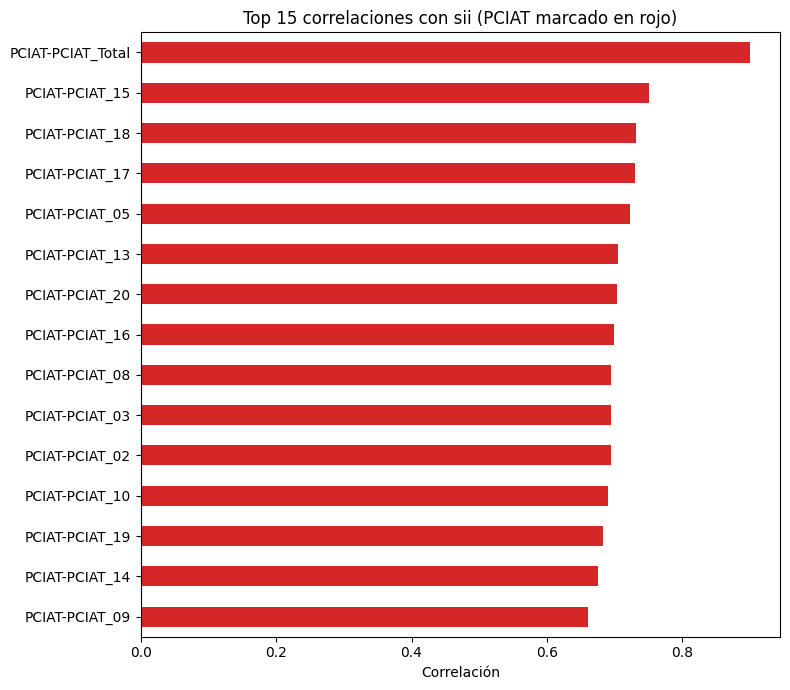

In [14]:
# Visualización: las variables PCIAT-* deberían dominar (señal de leakage)
top_15 = (corr_target
          .drop(TARGET_COLUMN)
          .reindex(corr_target.drop(TARGET_COLUMN).abs().sort_values(ascending=False).index)
          .head(15))

colores = ['#d62728' if 'PCIAT' in v else '#1f77b4' for v in top_15.index]

plt.figure(figsize=(8,7))
top_15.iloc[::-1].plot(kind='barh', color=colores[::-1])
plt.title('Top 15 correlaciones con sii (PCIAT marcado en rojo)')
plt.xlabel('Correlación')
plt.tight_layout()
plt.show()


Las correlaciones más altas con `sii` corresponden a variables `PCIAT-*`, en particular `PCIAT-PCIAT_Total`, que alcanza una correlación cercana a `0.90`.

Esto **no** significa que sean buenos predictores: las variables `PCIAT-*` son justamente las que se utilizan para **construir** el target `sii` (Severity Impairment Index a partir del PCIAT), por lo que mantenerlas implicaría un caso claro de *data leakage* y produciría modelos artificialmente buenos.

Por esta razón, en la sección 10.2 se excluyen del dataset y en la sección 13 se vuelve a calcular la correlación sobre el dataset ya libre de leakage. Las correlaciones reales con el target, una vez removido el PCIAT, son moderadas o bajas, lo cual es esperable en problemas multifactoriales de comportamiento humano.

## 8. Hipótesis Iniciales

### 8.1 Hipótesis principal

Existe relación entre la actividad física, condición física y hábitos de sueño con el nivel de uso problemático de internet en niños y adolescentes.

### 8.2 Hipótesis secundarias
*   Un mayor tiempo diario frente a internet se relaciona con niveles más altos de *sii*.
*   Variables relacionadas con sueño podrían asociarse con comportamiento digital problemático.
*   Indicadores de condición física podrían tener relación con hábitos digitales.
*   El dataset presenta desbalance de clases que podría afectar el rendimiento de modelos de clasificación.

## 9. Comentarios

### 9.1 Justificación de eliminación futura de variables

El gráfico anterior muestra que algunas variables conceptualmente muy relevantes para la consigna (actividad física y condición física) presentan porcentajes muy altos de valores faltantes:

- `Fitness_Endurance-Max_Stage`, `Fitness_Endurance-Time_Mins` y `Fitness_Endurance-Time_Sec` (resistencia cardiovascular).
- `PAQ_A-Season` y `PAQ_A-PAQ_A_Total` (cuestionario de actividad física para adolescentes).
- `Physical-Waist_Circumference` (medida antropométrica).

Estas variables superan el 70% de valores faltantes y, aunque están alineadas con la pregunta de investigación, imputarlas con tan poca información disponible introduciría ruido y sesgo. Por eso, en la sección 10.3 se aplicará un umbral de eliminación del 70% como compromiso entre conservar información útil y no inventarla.

Caso especial — `PAQ_C-PAQ_C_Total`: tiene aproximadamente 56% de nulos, pero al ser el equivalente del PAQ para niños se decide **conservarla** dado que es central para la hipótesis del proyecto. Este compromiso se reconoce como una limitación a documentar en los resultados.

### 9.2 Sobre el leakage

Las variables PCIAT fueron excluidas debido a que están directamente relacionadas con la construcción del target (sii), lo cual podría generar data leakage y producir resultados artificialmente altos.